# Here we inspect serotonergic gene expression interpolation
Please refer to notebook `get_genes` for how the data was generated

In [3]:
import sys
sys.path.append('../')

from config import *
from figs_config import *

Loaded aesthetics module


## Data specs

In [85]:
import pandas as pd
mappings = pd.read_csv(projdir + '/data/beliveau2017_serotonergic_names_mappings.csv')

In [86]:
space = "fsLR-4k"
strategy = "all"
percentage = "100"

# Aesthetics

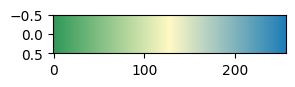

In [87]:
import matplotlib.pyplot as plt

blue = plt.cm.BuGn(0.7)
green = plt.cm.YlOrBr(.1)
yellow = plt.cm.GnBu(0.8)

bgy,_ = three_colours_gradient(lo=blue, mid=green, hi=yellow)

In [127]:
import seaborn as sns

gene_colours = plt.cm.viridis_r(np.linspace(0.3, 0.9, len(mappings['gene'])))
sns.color_palette(gene_colours)

[(0.266941, 0.748751, 0.440573),
 (0.119423, 0.611141, 0.538982),
 (0.163625, 0.471133, 0.558148),
 (0.231674, 0.318106, 0.544834),
 (0.282623, 0.140926, 0.457517)]

# 1. Sparse to continuous

## Cross validation - five-fold with random samples

In [89]:
import joblib

all_runs_rank_scores = joblib.load(projdir + '/results/use_case_microarray_cv_mean_ranks.pkl')
all_runs_rank_scores = all_runs_rank_scores.drop(columns=['delta', 'theta','alpha','beta','gamma1','gamma2'], axis = 1)

In [90]:
all_runs_rank_scores

,HTR1A,HTR1B,HTR2A,HTR4,SLC6A4
krige,0.952381,NaN,0.952381,0.976190,NaN
regkrige,0.857143,NaN,0.785714,0.547619,NaN
knn,0.666667,0.857143,0.690476,0.714286,0.821429
rbf,0.476190,0.571429,0.476190,0.428571,0.928571
idw,0.380952,0.500000,0.428571,0.666667,0.500000
swr,0.166667,0.571429,0.166667,0.166667,0.250000


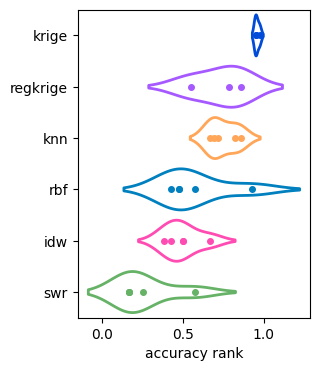

In [91]:
import seaborn as sns

plt.figure(figsize=(3,4))
sns.violinplot(all_runs_rank_scores.T, fill=False, orient = 'h',palette=apal, inner = 'points', linewidth = 2, legend = False)
plt.xlabel("accuracy rank")
plt.savefig(projdir + '/figs/main/use_case_microarray_cv_mean_ranks_all_genes.svg')

In [92]:
import joblib
from interpmodules import helpers

src_pvdata = joblib.load(projdir + f'/data/icbm09c_left-volume_microarray-pet.pkl')
sampling = helpers.cv_random_noreplace(pvdata=src_pvdata, nfolds=5, rseed=321)

402


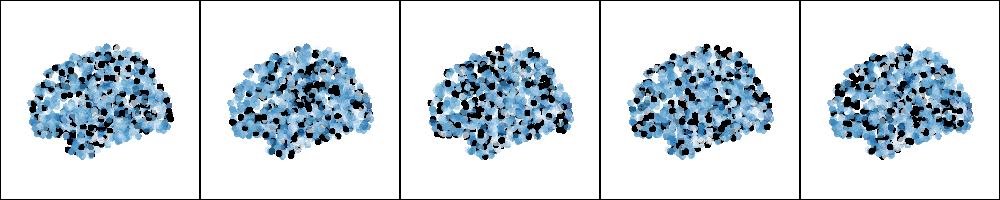

In [93]:
import pyvista as pv

pl = pv.Plotter(shape=(1,5), window_size = (1000,200))

for i in range(5):
    pl.subplot(0,i)
    pl.add_points(pv.PolyData(sampling[0][i]).rotate_z(180), scalars = src_pvdata['mrna_HTR1A'][sampling[1][i]], \
              cmap = 'Blues', point_size = 7, opacity = .7, show_scalar_bar=False, **point_aes)
    pl.add_points(pv.PolyData(sampling[2][i]).rotate_z(180), point_size = 7, color = 'k', opacity = 1, **point_aes)
    pl.camera_position = 'yz'
pl.show(jupyter_backend = 'static')
pl.save_graphic(projdir + '/figs/main/use_case_microarray_random_cv_example_HTR1A.svg')

## Cross validation - five-fold with distance-dependent samples centered around the DSK33 parcellation

In [ ]:
######### Waiting for code to run

# 2. Variography

In [94]:
space = "fsLR-4k"
strategy = "all"
percentage = "100"
datasource = "microarray-pet"

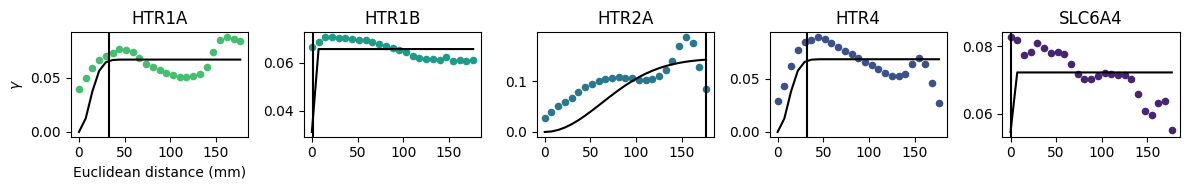

In [95]:
from interpmodules import helpers, metrics
import joblib
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1,5, figsize = (12, 2), sharex=True)
variogram_gof = dict.fromkeys(mappings['gene'])


for gi, gene in enumerate(mappings['gene']):

    maptag = f"mrna_{gene}"

    results = joblib.load(projdir + f'/results/{datasource}/{strategy}/{space}_mrna_{gene}_cic-volume_{datasource}_samp-{strategy}_pct-{percentage}_0_all_info.pkl')    
    x,y,N,eff_range,psill,nugg = results['variogram']
    
    fit = [ helpers.gaussian(h=xi, r=eff_range, c0=psill, nugget=nugg) for xi in x ]

    joined = np.concat([y,fit])
    rescaled = ( joined - joined.min() ) / ( joined.max() - joined.min() )
    rescaled_y = rescaled[:len(x)]
    rescaled_fit = rescaled[len(x):]
    variogram_gof[gene] = np.mean(metrics.metric(rescaled_fit, rescaled_y, 'residual'))
    
    axs[gi].scatter(x,y, color = gene_colours[gi], s=20)
    axs[gi].plot(x, fit, c='k')
    axs[gi].axvline(eff_range, c = 'k')
    axs[gi].set_title(gene)
axs[0].set_xlabel("Euclidean distance (mm)")
axs[0].set_ylabel(r"$\gamma$")
    
plt.tight_layout()
plt.savefig(projdir + '/figs/main/use_case_microarray_variograms')

In [25]:
src_pvdata = joblib.load(projdir + f'/data/icbm09c_cic-volume_microarray-pet.pkl')

ctx_dsk33 = joblib.load(projdir + '/data/fsLR-4k_midthickness_parc-dsk33.pkl')

# re-register them to icbm09
mni_cents = fslr_to_mni_coords_transform(coords = ctx_dsk33[2], inverse=True)

# Highlight HTR1A in the main figure

402


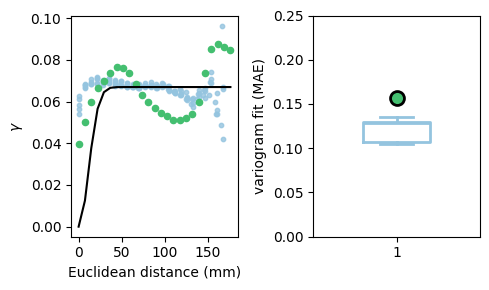

In [128]:
from interpmodules import metrics
gene = 'HTR1A'

all_variogram_gof_emp = []
all_variogram_gof_cv = []

fig, axs = plt.subplots(1,2, figsize = (5,3))

maptag = f"mrna_{gene}"
datasource = f"microarray-pet"    

results = joblib.load(projdir + f'/results/microarray-pet/all/{space}_{maptag}_cic-volume_{datasource}_samp-{strategy}_pct-{percentage}_0_all_info.pkl')
x,y,N,eff_range,psill,nugg = results['variogram']

fit = [ helpers.gaussian(h=xi, r=eff_range, c0=psill, nugget=nugg) for xi in x ]

joined = np.concat([y,fit])
rescaled = ( joined - joined.min() ) / ( joined.max() - joined.min() )
rescaled_y = rescaled[:len(x)]
rescaled_fit = rescaled[len(x):]

variogram_gof_emp = np.mean(metrics.metric(rescaled_fit, rescaled_y, 'residual'))

axs[0].scatter(x,y, color=gene_colours[mappings['gene'] == gene], s=20, zorder = 5)

#for j in range(mni_cents.shape[0]):

center = mni_cents[j,:]
#sampling = helpers.cv_distdep_noreplace(pvdata=src_pvdata, center=center, nfolds=5, rseed=321)
sampling = helpers.cv_random_noreplace(pvdata=src_pvdata, nfolds=5,rseed=321)
variogram_gof_cv = []

for i in range(5):
    X = sampling[0][i]
    train_vals = src_pvdata[maptag][sampling[1][i].astype(int)]
    D = helpers.internal_distance_matrix(X, 'euclidean')
    vario =  helpers._get_empirical_variogram(x=train_vals ,D=D,nh=25,h_bounds=0)

    joined = np.concat([vario[1],fit])
    rescaled = ( joined - joined.min() ) / ( joined.max() - joined.min() )
    rescaled_y = rescaled[:len(x)]
    rescaled_fit = rescaled[len(x):]
    variogram_gof_cv.append( np.mean(metrics.metric(rescaled_fit, rescaled_y, 'residual')) )
    
    axs[0].scatter(vario[0], vario[1], color=plt.cm.Blues(0.4), s=10, alpha = 0.8)
axs[0].plot(x, fit, c='k', zorder = 10)
#axs.axvline(eff_range, c = 'k')
axs[0].set_xlabel("Euclidean distance (mm)")
axs[0].set_ylabel(r"$\gamma$")
all_variogram_gof_cv += variogram_gof_cv

axs[1].boxplot(all_variogram_gof_cv, widths = 0.4, \
            medianprops=dict(color=plt.cm.Blues(0.4), linewidth=2),\
           whiskerprops=dict(color=plt.cm.Blues(0.4), linewidth=2),\
           capprops=dict(color=plt.cm.Blues(0.4), linewidth=2),\
           boxprops=dict(color=plt.cm.Blues(0.4), linewidth=2),\
           flierprops = dict(marker='o', markerfacecolor=plt.cm.Blues(0.4), 
                  markersize=8, 
                  linestyle='none', 
                  markeredgecolor=bgy(0.0)))
axs[1].scatter(x=1, y=np.mean(variogram_gof_emp),\
               color = gene_colours[mappings['gene'] == gene], linewidth = 2, edgecolor = 'k', s=100, zorder = 10)
axs[1].set_ylim([0,0.25])
axs[1].set_xlabel('')
axs[1].set_ylabel('variogram fit (MAE)')

plt.tight_layout()
#plt.show()
plt.savefig(projdir + '/figs/main/cv_HTR1A_variogram_and_fit_distdep.svg')

In [60]:
variogram_gof_plotdata = pd.DataFrame(variogram_gof.values(), index = variogram_gof.keys())

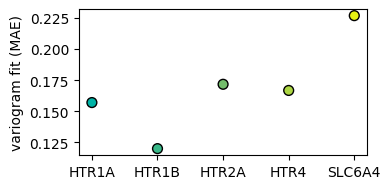

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize = (4,2))
    
plt.scatter(y=variogram_gof_plotdata, x=variogram_gof_plotdata.index, s = 50, edgecolor = 'k', c=gene_colours)
plt.ylabel("variogram fit (MAE)")
plt.tight_layout()

plt.savefig(projdir + '/figs/main/use_case_microarray_genes_variogram_fit.svg')

# 3. Interpolated maps

In [17]:
reduced_mesh = joblib.load(projdir + f'/data/{space}_reduced-midthickness_beliveau.pkl')

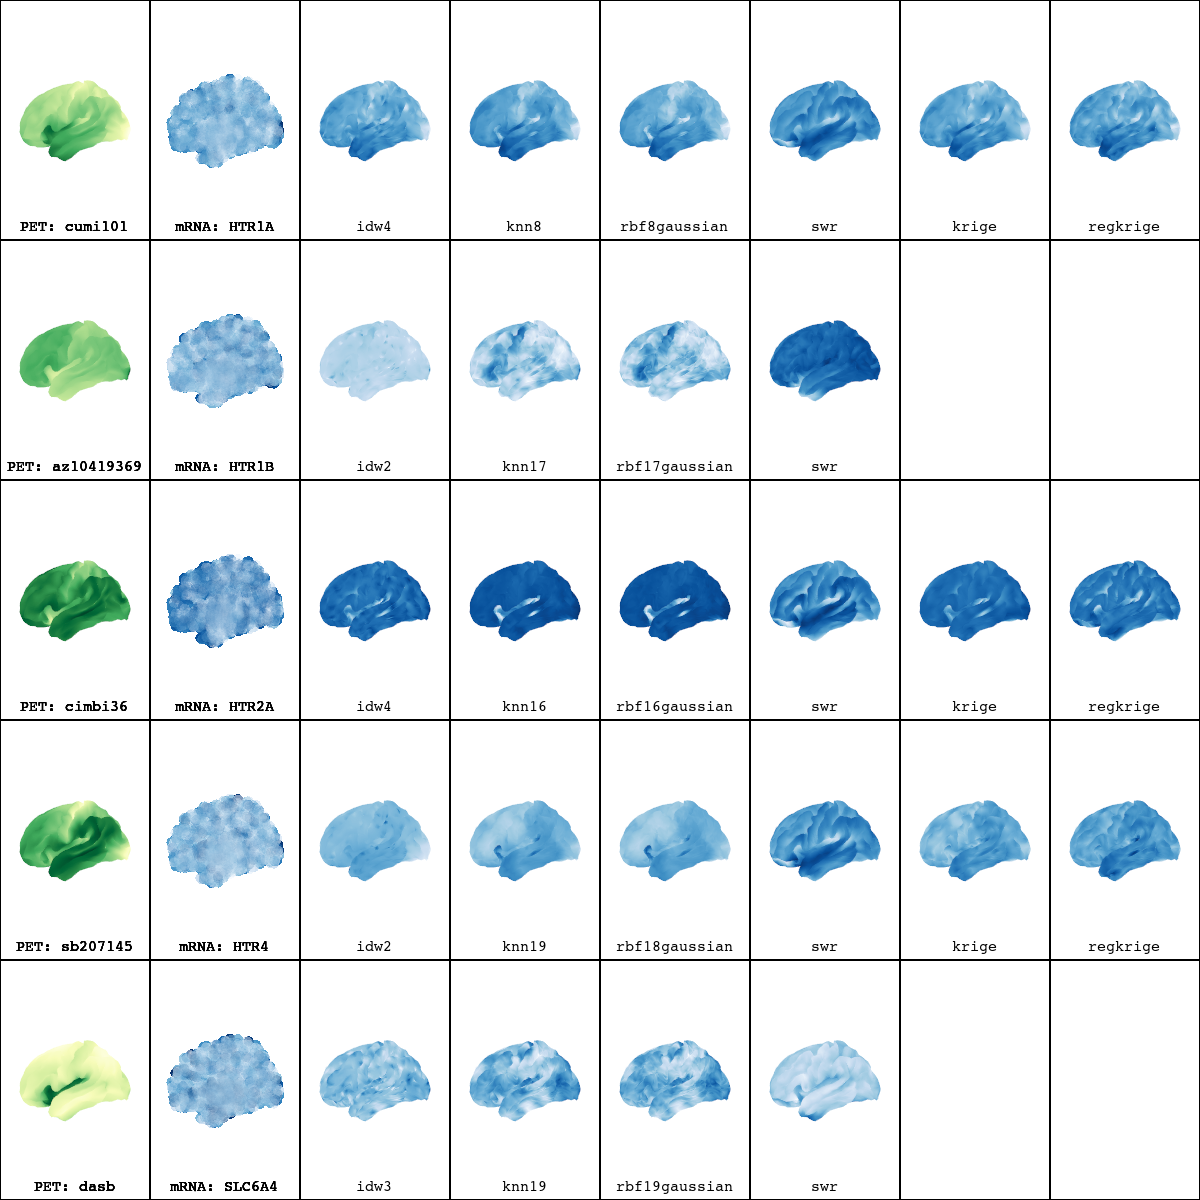

In [21]:
import pyvista as pv
datasource='microarray-pet'
pl = pv.Plotter(shape = (len(mappings['gene']), len(approaches) + 2), window_size = (1200, 1200))

src_pvdata = joblib.load(projdir + f'/data/icbm09c_left-volume_microarray-pet.pkl')

for gi, gene in enumerate(mappings['gene']):

    compare_maptag = f"pet_beliveau2017_{mappings['tracer'][gi]}"
    
    maptag = f"mrna_{gene}"

    results = joblib.load(projdir + f'/results/{datasource}/{strategy}/{space}_mrna_{gene}_cic-volume_{datasource}_samp-{strategy}_pct-{percentage}_0_all_info.pkl')    
    
    for ai, approach in enumerate(approaches):

        if approach == 'idw':
            approach_label = results['interpolant_labels'][0]
        elif approach == 'knn':
            approach_label = results['interpolant_labels'][1]
        elif approach == 'rbf':
            approach_label = results['interpolant_labels'][2]

        else: approach_label = approach
        pl.subplot(gi, 0)
        pl.add_mesh(reduced_mesh.rotate_z(180), scalars = compare_maptag, cmap = "YlGn", **mesh_aes)
        pl.add_text(f"PET: {mappings['tracer'][gi]}", position = "lower_edge", font = "courier", font_size = 7)
        pl.camera_position = "yz"

        pl.subplot(gi, 1)
        pl.add_points(src_pvdata.rotate_z(180), scalars = maptag, cmap = "Blues", \
                      point_size = 5, show_scalar_bar=False, opacity = .7, **point_aes)
        pl.add_text(f"mRNA: {gene}", position = "lower_edge", font = "courier", font_size = 7)
        pl.camera_position = "yz"
        
        pl.subplot(gi, ai + 2)
        if not isinstance(results['interpolated'][approach], np.ndarray): continue
        pl.add_mesh(reduced_mesh.rotate_z(180), scalars = results['interpolated'][approach], cmap = "Blues", **mesh_aes)
        pl.add_text(approach_label, position = "lower_edge", font = "courier", font_size = 7)
        pl.camera_position = "yz"
        
pl.show(jupyter_backend = 'static')
pl.save_graphic(projdir + '/figs/main/use_case_microarray_interpolated.svg')

# Show case the HTR1A

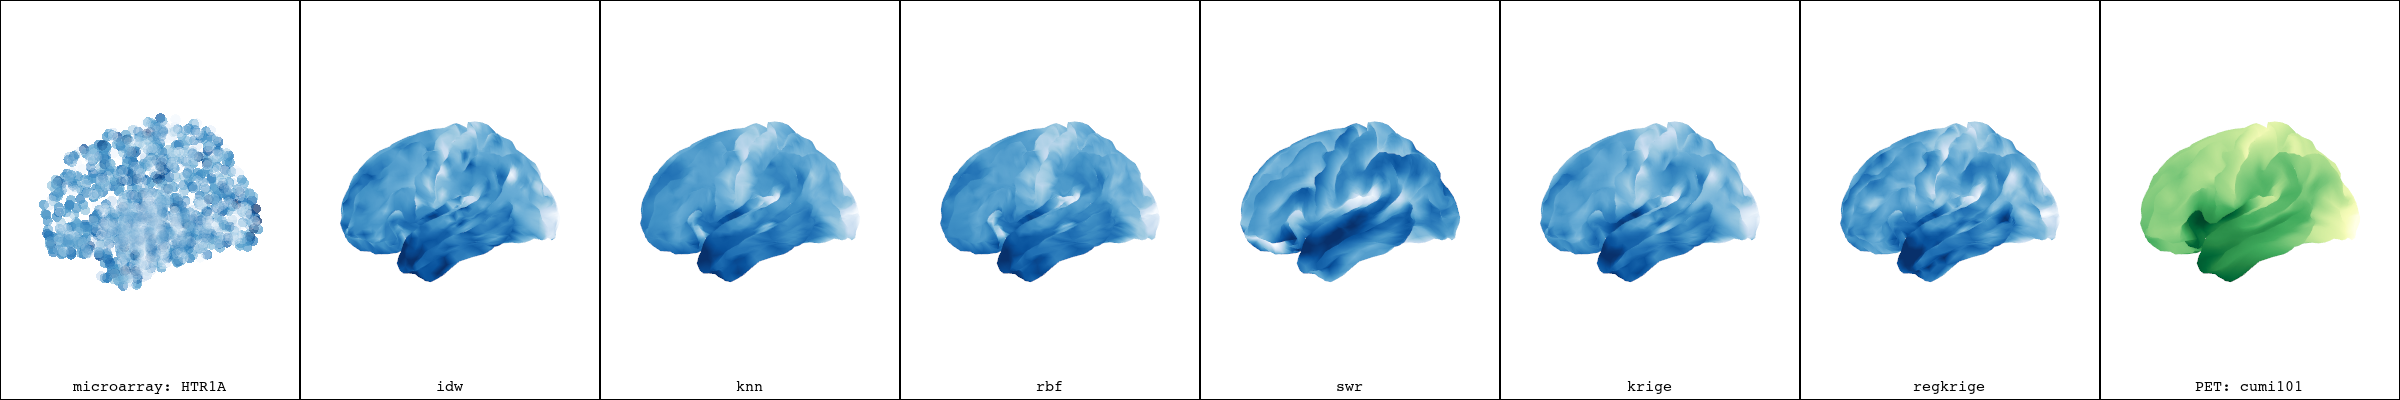

In [103]:
import pyvista as pv

gene = 'HTR1A'
corr = dict.fromkeys(approaches)
    
compare_maptag = f"pet_beliveau2017_{mappings['tracer'][0]}"
maptag = f"mrna_{gene}"
src_pvdata = joblib.load(projdir + f'/data/icbm09c_left-volume_microarray-pet.pkl')
results = joblib.load(projdir + f'/results/{datasource}/{strategy}/{space}_mrna_{gene}_cic-volume_{datasource}_samp-{strategy}_pct-{percentage}_0_all_info.pkl')    

pl = pv.Plotter(shape = (1,len(approaches) + 2), window_size = (2400, 400))

pl.subplot(0,0)
pl.add_points(src_pvdata.rotate_z(180), scalars = f"mrna_{gene}", cmap = "Blues", \
                      clim = (np.percentile(src_pvdata[f"mrna_{gene}"], 1), np.percentile(src_pvdata[f"mrna_{gene}"], 99)), \
                      point_size = 10, opacity = 0.7, show_scalar_bar=False, **point_aes)
pl.add_text(f"microarray: {gene}", position = "lower_edge", font = "courier", font_size = 7)
pl.camera_position = "yz"

pl.subplot(0,7)
pl.add_mesh(reduced_mesh.rotate_z(180), scalars = compare_maptag, \
            clim = (np.percentile(reduced_mesh[compare_maptag], 1), np.percentile(reduced_mesh[compare_maptag], 99)),\
            cmap = "YlGn", **mesh_aes)
pl.add_text(f"PET: {mappings['tracer'][0]}", position = "lower_edge", font = "courier", font_size = 7)
pl.camera_position = "yz"

for ai, approach in enumerate(approaches):
    pl.subplot(0,ai + 1)
    if not isinstance(results['interpolated'][approach], np.ndarray): continue
    pl.add_mesh(reduced_mesh.rotate_z(180), \
                scalars = results['interpolated'][approach], \
                cmap = "Blues", clim = (np.percentile(results['interpolated'][approach], 1), np.percentile(results['interpolated'][approach], 99)),\
                **mesh_aes)
    pl.add_text(approach, position = "lower_edge", font = "courier", font_size = 7)

    corr[approach] = np.corrcoef( results['interpolated'][approach], reduced_mesh[compare_maptag] )[1,0]
    
    pl.camera_position = "yz"

pl.show(jupyter_backend = 'static')
pl.save_graphic(projdir + '/figs/main/use_case_microarray_HTR1A.svg')

# Spatial nulls for every receptor gene, need to save them so I can plot the HTR1A more in depth

In [16]:
from interpmodules import helpers

D = helpers.internal_distance_matrix(v=reduced_mesh.points, f=None, method = 'euclidean', n_proc = -1)

In [18]:
from brainspace.null_models import MoranRandomization
msr = MoranRandomization(n_rep=1000, procedure='singleton', tol=1e-6,
                         random_state=321)
msr.fit(D)

MoranRandomization(n_rep=1000, random_state=321, tol=1e-06)

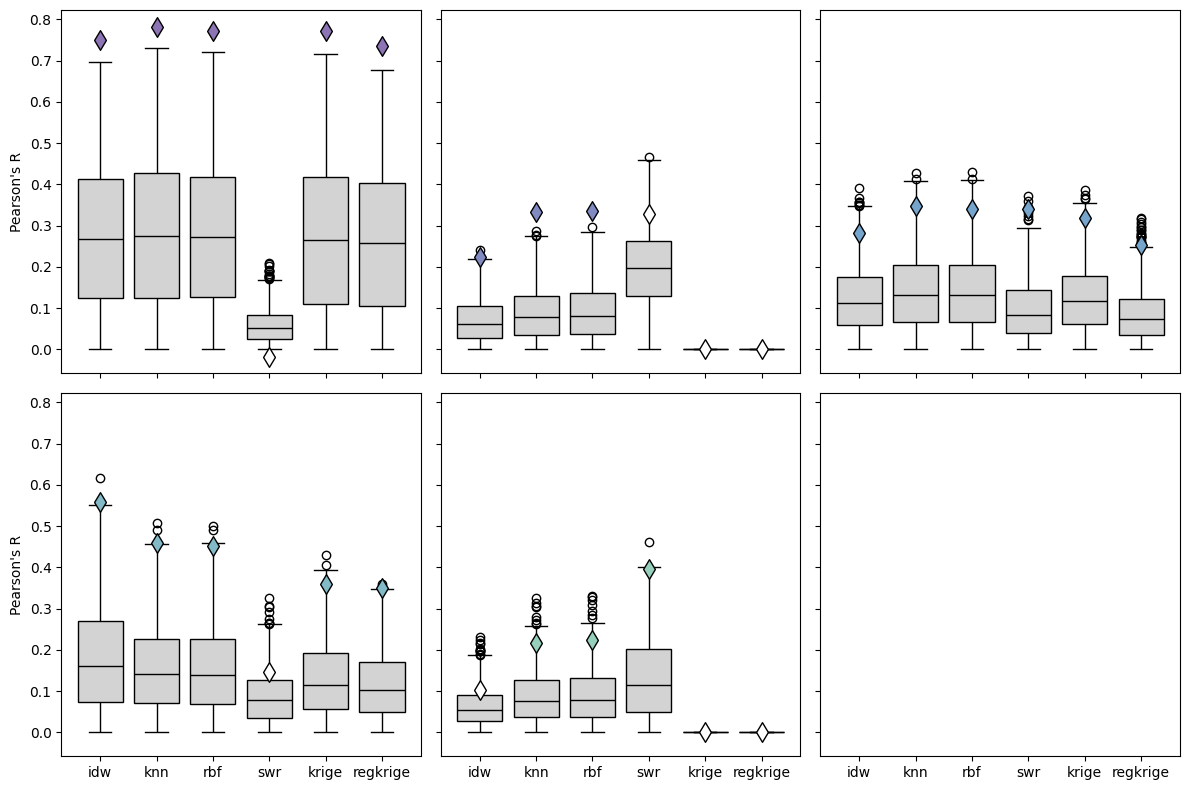

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

plot = False

fig, axs = plt.subplots(2,3, figsize = (12, 8), sharey=True, sharex=True)
datasource = 'microarray-pet'

for gi, gene in enumerate(mappings['gene']):

    row = gi // 3
    col = gi % 3
    
    emp_r = dict.fromkeys(approaches)
    pvals = dict.fromkeys(approaches)
    all_nulldistr = dict.fromkeys(approaches)

    compare_maptag = f"pet_beliveau2017_{mappings['tracer'][gi]}"
    maptag = f"mrna_{gene}"
    results = joblib.load(projdir + f'/results/{datasource}/{strategy}/{space}_mrna_{gene}_cic-volume_{datasource}_samp-{strategy}_pct-{percentage}_0_all_info.pkl')    

    if plot:
        # null distribution histograms
        fig1, axs1 = plt.subplots(2,3, figsize = (8,3))
    for ai, approach in enumerate(approaches):

        if plot: row, col = ai // 3, ai % 3

        dt = results['interpolated'][approach]
        if not isinstance(results['interpolated'][approach], np.ndarray): emp_r[approach] = 0; pvals[approach] = 1; all_nulldistr[approach] = np.zeros(1000); continue
        else: emp_r[approach] = np.corrcoef( results['interpolated'][approach].flatten(), reduced_mesh[compare_maptag] )[1,0]
        
        mrnulls = msr.randomize(dt)
        nulldistr = [ abs(np.corrcoef( mrnulls[i,:], reduced_mesh[compare_maptag]) )[1,0] for i in range(1000)]
        all_nulldistr[approach] = np.array(nulldistr)
        
        pvals[approach] = np.mean(np.abs(nulldistr) >= np.abs(emp_r[approach]))

        if plot:
            axs1[row, col].set_title(approach)
            axs1[row, col].hist(nulldistr, facecolor = 'lightgray', bins = 25)
            axs1[row, col].axvline(emp_r[approach], color = gene_colours[gi])
            
    if plot:
        plt.tight_layout()
        plt.savefig(projdir + f'/figs/main/use_case_microarray_compare_pet_{gene}_histograms.svg')
        plt.close(fig1)
    
    nulldistr_plotdata = pd.DataFrame(all_nulldistr)
    df = pd.DataFrame([emp_r, pvals], index = ['r', 'p'])
    df = df.T
    is_significant = df['p'] < .05

    sns.boxplot(nulldistr_plotdata, linecolor = 'k', color = 'lightgray', ax=axs[row, col])
    axs[row, col].scatter(
        df.index[~is_significant],
        df['r'][~is_significant],
        color="w",
        marker = 'd',
        edgecolor = 'k',
        s=100,
        zorder=5,
        label="Not significant"
    )
    axs[row, col].scatter(
        df.index[is_significant],
        df['r'][is_significant],
        color=gene_colours[gi],
        marker = 'd',
        edgecolor = 'k',
        s=100,
        zorder=5,
        label="Significant"
    )
    axs[row, 0].set_ylabel("Pearson's R")
    joblib.dump((df, nulldistr_plotdata), projdir + f'/results/use_case_microarray_{gene}_nulldistr.pkl')
plt.tight_layout()
plt.savefig(projdir + f'/figs/main/use_case_microarray_compare_pet_moran_nulls_boxplot.svg')

In [1]:
import joblib

In [4]:
df, nulldistr = joblib.load(projdir + '/results/use_case_microarray_HTR1A_nulldistr.pkl')

In [5]:
df = df.sort_values(by = 'r', ascending = False)

In [6]:
df

,r,p
knn,0.782508,0.000
krige,0.772502,0.000
rbf,0.770526,0.000
idw,0.748920,0.000
regkrige,0.734977,0.000
swr,-0.017895,0.824


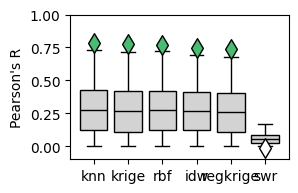

In [71]:
import seaborn as sns
gene = 'HTR1A'
is_significant = df['p'] < .05

fig, ax = plt.subplots(figsize = (3,2))
sns.boxplot(nulldistr, order = df.index, linecolor = 'k', fliersize = 0, color = 'lightgray', ax=ax)
ax.scatter(
    df.index[~is_significant],
    df['r'][~is_significant],
    color="w",
    marker = 'd',
    edgecolor = 'k',
    s=100,
    zorder=5,
    label="Not significant"
)
ax.scatter(
    df.index[is_significant],
    df['r'][is_significant],
    color=gene_colours[mappings['gene'] == gene],
    marker = 'd',
    edgecolor = 'k',
    s=100,
    zorder=5,
    label="Significant"
)
ax.set_ylabel("Pearson's R")
plt.tight_layout()
plt.ylim([-0.1,1])
#plt.show()
plt.savefig(projdir + f'/figs/main/use_case_microarray_{gene}_spatialnulls.svg')

# Try distance dependent

In [6]:
import sys
sys.path.append("../")

from config import *
from figs_config import *

In [7]:
# load dsk centroids
import joblib
sphere_dsk33 = joblib.load( projdir + '/data/fsLR-4k_sphere_parc-dsk33.pkl')
ctx_dsk33 = joblib.load(projdir + '/data/fsLR-4k_midthickness_parc-dsk33.pkl')

# re-register them to icbm09
mni_cents = fslr_to_mni_coords_transform(coords = ctx_dsk33[2], inverse=True)

In [9]:
import wrappers
from interpmodules import deterministic, geospatial, helpers, metrics
import pandas as pd

gene = 'HTR1A'
maptag = f"mrna_{gene}"
datasource = f"microarray-pet"
src_pvdata = joblib.load(projdir + f'/data/icbm09c_cic-volume_microarray-pet.pkl')
#cov = wrappers.generate_covariates(curr_map=maptag, src_polydata=src_pvdata, \
#                         trg_polydata=None, nspins=0, datasource=datasource)
M = {}
run_metric_scores = pd.DataFrame()
#approach = 'knn'
#_,_,_,mdf_concat = deterministic._find_param_best_random_chunks(method=approach, pvdata=src_pvdata, known_coords=src_pvdata.points, \
#                                                               full_map=src_pvdata[f"{fband}_zscored_no_outlier"], n_chunks=5, seed=321)

all_run_rank_scores = pd.DataFrame(columns = range(mni_cents.shape[0]) )
                                   
for j in range(mni_cents.shape[0]):
    center = mni_cents[j,:]
    
    for approach in approaches:

        if approach in ['idw', 'knn', 'rbf']:
            _,_,_,mdf_concat = deterministic._find_param_best_cv(method=approach, \
                                                                 pvdata=src_pvdata, \
                                                                    known_coords=src_pvdata.points, \
                                                                   full_map=src_pvdata[maptag], \
                                                                 distdep = True, center = center,\
                                                                 nfolds=5, seed=321)
            M[approach] = mdf_concat

        #if approach in ['swr', 'krige', 'regkrige']:
        #    mdf_concat = geospatial._iterate_chunks(method=approach, pvdata=src_pvdata, covariates=cov, \
        #full_map=src_pvdata[f"{fband}_zscored_no_outlier"], center = center, distdep = True, nfolds=5, seed=321)
        #    M[approach] = mdf_concat
        
        else: continue
    
        run_metric_scores[approach] = M[approach].mean(axis=1)
    
    run_rank_scores = metrics.accuracy_rank(run_metric_scores)
    run_rank_scores = np.mean(run_rank_scores, axis = 1)
    all_run_rank_scores[j] = run_rank_scores
#joblib.dump(M, projdir + f'/results/use_case_intracranial_{fband}_cv.pkl')

4
3
4
4
4
10
8
8
9
12
6 gaussian
                    2 gaussian  3 gaussian  4 gaussian  5 gaussian  \
pearson               0.653877    0.663827    0.661900    0.668593   
spearman              0.611692    0.613188    0.610055    0.623440   
ssim                  0.999689    0.999704    0.999718    0.999721   
r2                    0.187648    0.123570    0.048162    0.001236   
rmse                  0.228473    0.221456    0.220024    0.217400   
kolmogorov_smirnov    0.139769    0.184438    0.210375    0.226225   
jensen_shannon        0.090266    0.086757    0.086424    0.085000   

                    6 gaussian  7 gaussian  8 gaussian  9 gaussian  \
pearson               0.676940    0.672948    0.672391    0.667494   
spearman              0.637230    0.625757    0.626157    0.619447   
ssim                  0.999732    0.999729    0.999731    0.999726   
r2                   -0.025057   -0.081409   -0.123726   -0.170343   
rmse                  0.214432    0.215283    0.215325  

<Axes: >

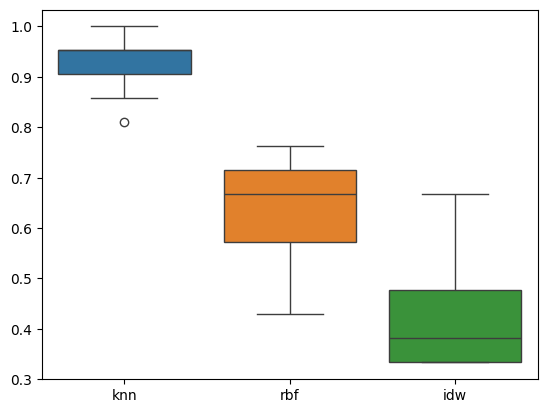

In [11]:
import seaborn as sns

sns.boxplot(all_run_rank_scores.T)

In [15]:
for approach in ['idw', 'knn', 'rbf']:
    run_metric_scores[approach] = M[approach].mean(axis=1)
run_rank_scores = metrics.accuracy_rank(run_metric_scores)
run_rank_scores = np.mean(run_rank_scores, axis = 1)

In [17]:
all_runs_metric_scores = pd.DataFrame()

for approach in ['idw', 'knn', 'rbf']:
    tmp = M[approach].T
    tmp.index = np.array([approach + str(i) for i in range(5)])
    all_runs_metric_scores = pd.concat( [all_runs_metric_scores, tmp])

In [18]:
all_runs_rank_scores = metrics.accuracy_rank(all_runs_metric_scores.T)
#run_rank_scores = np.mean(run_rank_scores, axis = 1)
all_runs_rank_scores = all_runs_rank_scores.mean(axis = 1)
all_runs_rank_scores = pd.DataFrame( all_runs_rank_scores )

all_runs_rank_scores['approach'] = [ all_runs_rank_scores.index[i][:-1] for i in range(len(all_runs_rank_scores))]
all_runs_rank_scores['fold'] = [ all_runs_rank_scores.index[i][-1] for i in range(len(all_runs_rank_scores))]

all_runs_rank_scores.columns = ['rank', 'approach', 'iteration']

In [20]:
order = all_runs_rank_scores.groupby('approach').median('rank').sort_values('rank', ascending = False).index

Text(0.5, 0, '')

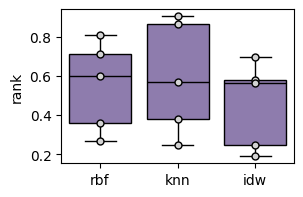

In [22]:
import seaborn as sns
plt.figure(figsize = (3,2))
sns.boxplot(all_runs_rank_scores, y= 'rank', order = order, color = gene_colours[0], linecolor = 'k', x = 'approach')
sns.pointplot(all_runs_rank_scores, y='rank', x = 'approach', hue = 'iteration', markeredgewidth = 1, markeredgecolor = 'k', markerfacecolor = 'lightgray', markersize = 5, linestyle = 'none', legend = False, zorder = 5)
plt.xlabel('')
#plt.savefig(projdir + '/figs/main/use_case_ieeg_alpha_cv_ranks.svg')

In [23]:
full_mesh = joblib.load(projdir + '/data/fsLR-4k_full-midthickness_neuromaps_parc.pkl')

In [27]:
all_run_rank_scores = all_run_rank_scores.T

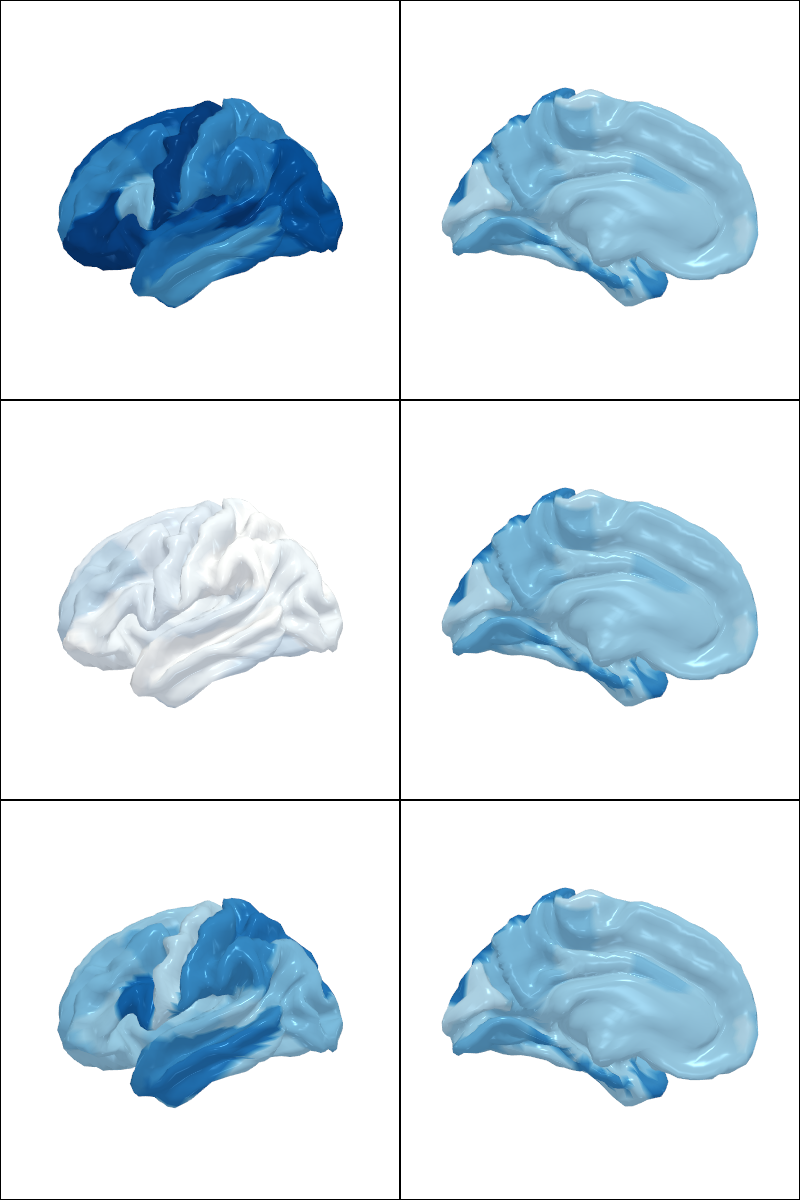

In [28]:
import pyvista as pv
pl = pv.Plotter(shape = (3,2), window_size = (800,1200))

for ai, approach in enumerate(['idw', 'knn', 'rbf']):
    cv_ctx = np.zeros(full_mesh.n_points)
    
    for lab in range(mni_cents.shape[0]):
        cv_ctx[ np.where( full_mesh['dsk33'] == lab )[0] ] = all_run_rank_scores.at[lab, approach]

    pl.subplot(ai, 0)
    pl.add_mesh(full_mesh.rotate_z(180), scalars = cv_ctx, cmap = 'Blues_r', \
                smooth_shading = True, ambient = .6, specular = 0.5, diffuse = 0.5, clim = (0.3,1), show_scalar_bar=False)
    pl.camera_position = 'yz'
    
    pl.subplot(ai, 1)
    pl.add_mesh(full_mesh, scalars = cv_ctx, cmap = 'Blues_r', smooth_shading = True, ambient = .6, specular = 0.5, diffuse = 0.5, clim = (0.3,1), show_scalar_bar=False)
    
    pl.camera_position = 'yz'
pl.show(jupyter_backend = 'static')

# This is just random samples

In [105]:
M = joblib.load(projdir + '/results/use_case_microarray_HTR1A_cv.pkl')

In [106]:
M = M[0]

In [107]:
run_metric_scores = pd.DataFrame()

for approach in approaches:
    run_metric_scores[approach] = M[approach].mean(axis=1)
run_rank_scores = metrics.accuracy_rank(run_metric_scores)
run_rank_scores = np.mean(run_rank_scores, axis = 1)

In [108]:
all_runs_metric_scores = pd.DataFrame()

for approach in approaches:
    tmp = M[approach].T
    tmp.index = np.array([approach + str(i) for i in range(5)])
    all_runs_metric_scores = pd.concat( [all_runs_metric_scores, tmp])


In [109]:
all_runs_rank_scores = metrics.accuracy_rank(all_runs_metric_scores.T)

In [110]:
all_runs_rank_scores = all_runs_rank_scores.mean(axis = 1)

In [111]:
all_runs_rank_scores = pd.DataFrame( all_runs_rank_scores )

In [112]:
all_runs_rank_scores['approach'] = [ all_runs_rank_scores.index[i][:-1] for i in range(len(all_runs_rank_scores))]
all_runs_rank_scores['fold'] = [ all_runs_rank_scores.index[i][-1] for i in range(len(all_runs_rank_scores))]

In [113]:
all_runs_rank_scores.columns = ['rank', 'approach', 'iteration']

In [114]:
order = all_runs_rank_scores.groupby('approach').median('rank').sort_values('rank', ascending = False).index
print(order)

Index(['krige', 'regkrige', 'knn', 'idw', 'rbf', 'swr'], dtype='object', name='approach')


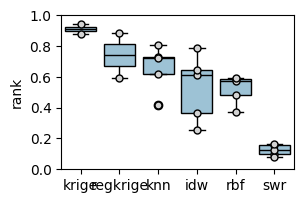

In [129]:
import seaborn as sns
plt.figure(figsize = (3,2))
sns.boxplot(all_runs_rank_scores, y= 'rank', order = order, color = plt.cm.Blues(0.4), \
            linecolor = 'k', x = 'approach')
sns.pointplot(all_runs_rank_scores, y='rank', x = 'approach', hue = 'iteration', \
              markeredgewidth = 1, markeredgecolor = 'k', markerfacecolor = 'lightgray', \
              markersize = 5, linestyle = 'none', legend = False, zorder = 5)
plt.ylim([0,1])
plt.xlabel('')
plt.savefig(projdir + '/figs/main/use_case_microarray_HTR1A_cv_ranks.svg')

# 4. Performances

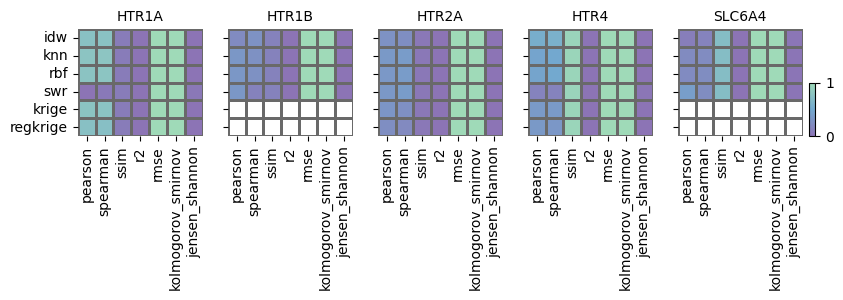

In [27]:
import seaborn as sns
import matplotlib.colors as mcolors
from matplotlib import cm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
fig, axs = plt.subplots(1, len(mappings['gene']), figsize = (10,2), sharey=True, sharex=True)

for gi, gene in enumerate(mappings['gene']):

    maptag = f"mrna_{gene}"

    results = joblib.load(projdir + f'/results/{datasource}/{strategy}/{space}_mrna_{gene}_cic-volume_{datasource}_samp-{strategy}_pct-{percentage}_0_all_info.pkl')    
    
    mean_metric_scores = results['performance'][0].loc[metrics_to_consider[:-1]].T
    
    sns.heatmap(mean_metric_scores, xticklabels=metrics_to_consider[:-1], yticklabels = approaches, \
                square=True, cmap = bgy, ax=axs[gi], linewidth =1, linecolor = 'dimgray', vmin=0, vmax = 1,cbar = False)
    #axs[0, pi].set_title(f'{p}%', fontsize = 10)
    axs[gi].set_title(gene, fontsize = 10)

axins = inset_axes(
    axs[-1],
    width="5%",  # width: 5% of parent_bbox width
    height="50%",  # height: 50%
    loc="lower left",
    bbox_to_anchor=(1.05, 0., 1, 1),
    bbox_transform=axs[-1].transAxes,
    borderpad=0,
)
norm = mcolors.Normalize(vmin=0, vmax=1)
cmap = bgy
fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), cax=axins)

fig.subplots_adjust(right=0.85, bottom = 0.2)
#plt.show()
plt.savefig(projdir + '/figs/main/use_case_microarray_performance_metrics.svg')